In [69]:
# Imports
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math

# Define coordinates
r, theta = sp.symbols('r theta')

# Define polar metric
g_polar = sp.Matrix([[1.0, 0.0],
                     [0.0, r**2]])
g_polar_inv = g_polar.inv()

# Compute Christoffel symbols
# This function will return a map of indices (i, j, k) to sympy expression
def christoffel_symbols(coords, g, g_inv):
    n = len(coords)
    Gamma = {}
    for i in range(n):
        for j in range(n):
            for k in range(n):
                expr = 0
                for l in range(n):
                    expr += g_inv[i, l] * (sp.diff(g[l, j], coords[k])
                                           + sp.diff(g[l, k], coords[j])
                                           - sp.diff(g[j, k], coords[l]))
                Gamma[(i,j,k)] = expr / 2  # sp.simplify(expr / 2)
    return Gamma

# Create the Gamma map for the metric
Gamma_polar = christoffel_symbols([r, theta], g_polar, g_polar_inv)

# Convert Christoffel symbols to numeric functions
# My understanding is that lambdify will take a sympy expression
# and convert it into a function that can be called with two arguments and return
# a floating point number; in other words, a function that evaluates the abstract 
# expression at the given point
Gamma_numeric_polar = {}
for key, expr in Gamma_polar.items():
    Gamma_numeric_polar[key] = sp.lambdify((r, theta), expr, "numpy")

# Display non-zero Christoffel symbols nicely
# This is provided so we can verify that the expression for each non-zero gamma
# are correct (in the case of the metric (1, 0, 0, 1/r) we get -r, 1/r, and 1/r
def print_nonzero_christoffel(Gamma, coords):
    print("Non-zero Christoffel symbols:")
    for key, value in Gamma.items():
        if value != 0:
            i, j, k = key
            print(f"Γ^{coords[i]}_{coords[j]}{coords[k]} = {value}")

print("\nPolar coordinates:")
print_nonzero_christoffel(Gamma_polar, ['r','theta'])



Polar coordinates:
Non-zero Christoffel symbols:
Γ^r_thetatheta = -1.0*r
Γ^theta_rtheta = 1.0/r
Γ^theta_thetar = 1.0/r


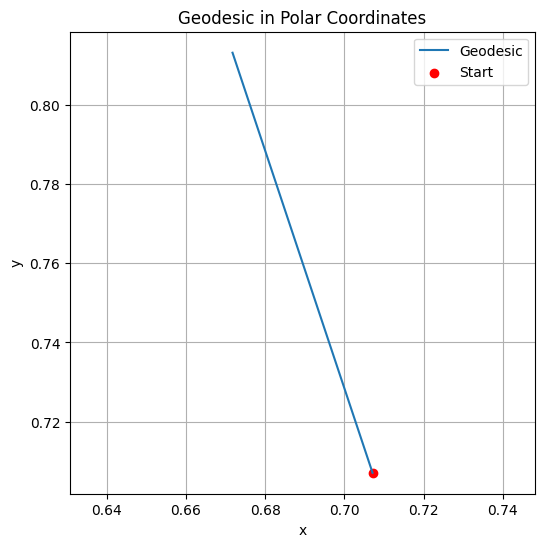

In [70]:
# Imports for numerical integration and plotting
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def geodesic_ode_diff(t, Y, coords, Gamma_funcs):
    hardcoded = geodesic_ode_hardcoded(t, Y, coords, Gamma_funcs)
    christoffel = geodesic_ode_christoffel(t, Y, coords, Gamma_funcs)
    
    diff = [a - b for a, b in zip(hardcoded, christoffel)]

    # Print results
    print(f"t={t:.3f}, Y={Y}")
    print(f"Hardcoded:   {hardcoded}")
    print(f"Christoffel: {christoffel}")
    print(f"Difference:  {diff}\n")
    
    return christoffel
    
def geodesic_ode(t, Y, coords, Gamma_funcs):
    # Unpack positions and velocities
    r_val, theta_val, dr_dt, dtheta_dt = Y
    q = [r_val, theta_val]
    v = [dr_dt, dtheta_dt]

    dqdt = [dr_dt, dtheta_dt]
    dvdt = [0.0, 0.0]

    # Evaluate numeric Gamma functions at current positions
    for i in range(2):
        s = 0.0
        for j in range(2):
            for k in range(2):
                gamma_ijk = Gamma_funcs[(i, j, k)]
                val = gamma_ijk(*q)
                s += val * v[j] * v[k]
        dvdt[i] = -s

    return [dqdt[0], dqdt[1], dvdt[0], dvdt[1]]

def geodesic_ode_hardcoded(t, Y, coords, Gamma_funcs):
    r_val, theta_val, dr_dt, dtheta_dt = Y
    
    dpdt = [dr_dt, dtheta_dt]
    dvdt = [0.0, 0.0]
    # Christoffel symbols
    dvdt[0] = r_val * dpdt[1]**2  # Γ^r_θθ = -r
    dvdt[1] = -2 * dpdt[0] * dpdt[1] / r_val  # Γ^theta_rtheta = 1/r, factor 2 for symmetry
    
    return [dpdt[0], dpdt[1], dvdt[0], dvdt[1]]

# Function to convert polar to Cartesian for plotting
def polar_to_cartesian(r_vals, theta_vals):
    x_vals = r_vals * np.cos(theta_vals)
    y_vals = r_vals * np.sin(theta_vals)
    return x_vals, y_vals

# Initial conditions and integration
# Example: start at r=1, theta=0, moving radially outward with dr/dt=0.5, dtheta/dt=1
Y0 = [1.0, math.pi /4, .5, 1.0]  # [r, theta, dr/dt, dtheta/dt]
t_span = (0, 0.1)
t_eval = np.linspace(t_span[0], t_span[1], 4000)

sol = solve_ivp(
    lambda t, Y: geodesic_ode(t, Y, ['r','theta'], Gamma_numeric_polar),
    t_span, Y0, t_eval=t_eval
)
# Convert to Cartesian for plotting
x_vals, y_vals = polar_to_cartesian(sol.y[0], sol.y[1])

# Step 6: Plot the geodesic
plt.figure(figsize=(6,6))
plt.plot(x_vals, y_vals, label='Geodesic')
plt.scatter([Y0[0]*np.cos(Y0[1])], [Y0[0]*np.sin(Y0[1])], color='red', label='Start')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Geodesic in Polar Coordinates')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()
